# Chapter 2: Masks and Filters

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter2_Masks_and_Filters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 1 finished with a scan whose numbers mean something — Hounsfield units, where fat sits
between −190 and −30 and muscle between −29 and +150.

This chapter turns those numbers into **selections**: deciding, for every single pixel, whether it
is fat, muscle, or not even part of the patient.

That is the heart of body composition analysis. Chapter 5 measures muscle and fat by counting
pixels in the right range — so everything that makes such a count trustworthy belongs here.

By the end you will be able to:

1. Read a histogram and use it to *choose* a cut-off instead of guessing one.
2. Build selections (called **masks**) and combine them.
3. Explain why selecting straight from a raw CT gives a broken, speckled result.
4. Fix that with **filters**, and know when to use which kind.
5. Tidy up a selection using its shape rather than its brightness.
6. Find edges — and see exactly where brightness alone stops being enough.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running on Colab: False
Working directory: /home/wxc151/projects/Biomedical-Image-Analysis-in-Python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

import medimage_data as md

vol, spacing, datasets = md.load_series(md.fetch_pancreas_ct(0))
dz, dy, dx = spacing

# Work on one slice from the middle of the scan.
sl = vol[len(vol) // 2].astype(np.float32)

# The area of a single pixel, in square centimetres. Every area we measure is
# just a pixel count multiplied by this.
px_area_cm2 = dy * dx / 100

print("slice size:", sl.shape)
print(f"one pixel = {px_area_cm2:.5f} cm^2")

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


slice size: (512, 512)
one pixel = 0.00807 cm^2


## 1. The histogram tells you where to cut

Before choosing any cut-off, look at how the values are distributed. A **histogram** counts how
many pixels fall into each brightness range.

A CT histogram is not a shapeless blob. It has bumps, and each bump is a tissue: lots of pixels
share a value because lots of pixels are the same stuff.

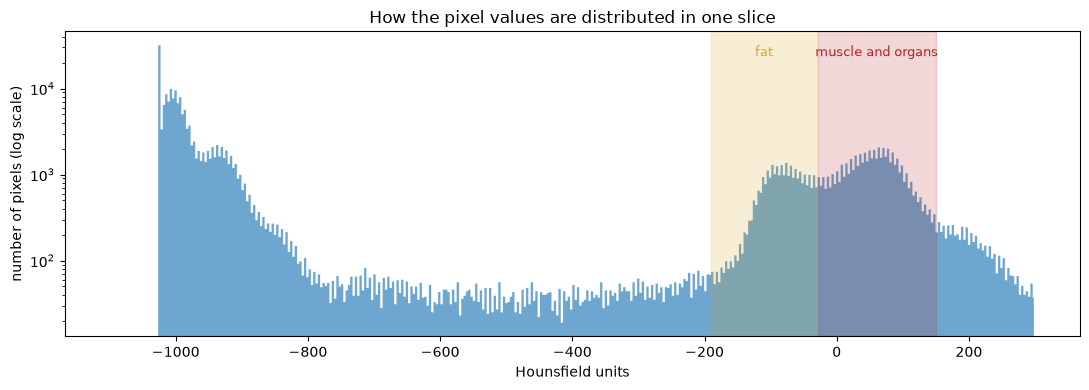

In [3]:
counts, edges = np.histogram(sl, bins=400, range=(-1100, 300))
centers = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(centers, counts, step="mid", alpha=0.65)
ax.set_yscale("log")               # log scale, or the air spike hides everything else
ax.set_xlabel("Hounsfield units")
ax.set_ylabel("number of pixels (log scale)")

for lo, hi, name, color in [(-190, -30, "fat", "goldenrod"),
                            (-29, 150, "muscle and organs", "firebrick")]:
    ax.axvspan(lo, hi, color=color, alpha=0.18)
    ax.text((lo + hi) / 2, counts.max(), name, ha="center", va="top",
            fontsize=9, color=color)

ax.set_title("How the pixel values are distributed in one slice")
plt.tight_layout()
plt.show()

The tall spike near −1000 is air — mostly the room around the patient. Then there is a wide bump
around −100 (fat) and another just above 0 (muscle and organs).

This is worth pausing on. The standard cut-offs are not arbitrary numbers somebody picked. They sit
in the **valleys between the bumps** — the places where one tissue ends and the next begins. The
histogram is where you can actually see that.

## 2. A mask is just an array of true and false

Ask a comparison question about an array and NumPy answers it for every pixel at once, giving back
an array of `True`/`False` the same size as the image. That is a **mask**.

Masks combine with three operators: `&` means *and*, `|` means *or*, `~` means *not*.

In [4]:
fat = (sl >= -190) & (sl < -30)
soft = (sl >= -29) & (sl < 150)

print("pixels selected as fat: ", fat.sum())
print("pixels selected as soft:", soft.sum())
print("what a mask contains:   ", fat.dtype)
print()
print(f"so the fat area would be {fat.sum() * px_area_cm2:.1f} cm^2 ...")

pixels selected as fat:  28337
pixels selected as soft: 57444
what a mask contains:    bool

so the fat area would be 228.7 cm^2 ...


### ...except that number is wrong

Plot the mask and the problem is obvious. The air outside the patient, the scanner table and the
padding all fall into one range or another. We just measured the furniture.

**Any measurement has to find the patient first.** The standard recipe has three steps:

1. Keep everything brighter than about −500 HU — that separates body from air.
2. Fill in enclosed holes, because lungs and bowel gas are inside the patient but full of air.
3. Keep only the largest connected blob — the body — and throw away the table.

In [5]:
def body_mask(slice_hu, threshold=-500):
    """Find the patient: the largest solid blob brighter than the threshold."""
    mask = ndi.binary_fill_holes(slice_hu > threshold)

    # label() gives every separate blob its own number.
    labels, n_blobs = ndi.label(mask)
    if n_blobs == 0:
        return mask

    sizes = ndi.sum_labels(np.ones_like(labels), labels, range(1, n_blobs + 1))
    biggest = int(np.argmax(sizes)) + 1
    return labels == biggest


body = body_mask(sl)

print(f"the patient fills {body.mean():.1%} of the picture")
print(f"fat inside the body : {(fat & body).sum() * px_area_cm2:7.1f} cm^2")
print(f"fat counted anywhere: {fat.sum() * px_area_cm2:7.1f} cm^2   <- the wrong answer")

the patient fills 36.0% of the picture
fat inside the body :   223.4 cm^2
fat counted anywhere:   228.7 cm^2   <- the wrong answer


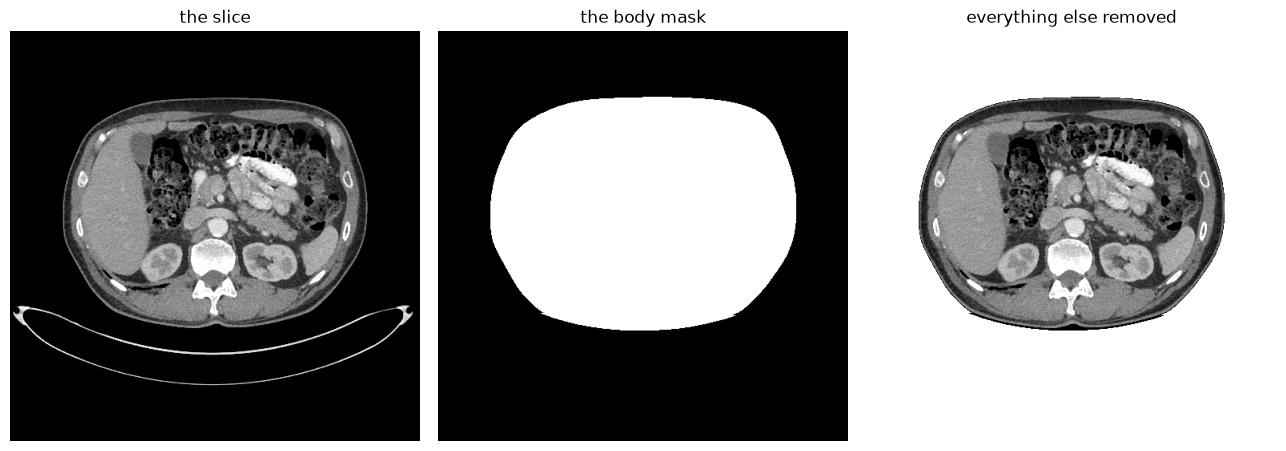

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(sl, cmap="gray", vmin=-160, vmax=240)
axes[0].set_title("the slice")
axes[1].imshow(body, cmap="gray")
axes[1].set_title("the body mask")
axes[2].imshow(np.where(body, sl, np.nan), cmap="gray", vmin=-160, vmax=240)
axes[2].set_title("everything else removed")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Two ways to use a mask

- `image[mask]` gives back a **flat list** of just the selected values. Use it to calculate
  averages and totals.
- `np.where(mask, image, something_else)` **keeps the picture shape**, replacing everything not
  selected. Use it to display.

For display, filling with `np.nan` ("not a number") is a handy trick: matplotlib leaves those
pixels blank instead of drawing them as 0, which would otherwise look like real tissue at 0 HU.

In [7]:
values = sl[fat & body]

print("the fat pixels inside the body:")
print(f"  how many : {values.size}")
print(f"  average  : {values.mean():7.1f} HU")
print(f"  spread   : {values.std():7.1f} HU")

the fat pixels inside the body:
  how many : 27677
  average  :   -82.4 HU
  spread   :    31.0 HU


## 3. Why selecting straight from a raw CT goes wrong

CT images are grainy. A scanner measures a limited number of X-ray photons, and that randomness
leaves a speckle of a few tens of HU on every pixel.

Now think about what that does at a cut-off. A pixel truly sitting at −28 HU might be recorded as
−31 and get excluded; its neighbour at −30 might be recorded as −27 and get included. Right at the
boundary, the grain flips pixels in and out at random.

The result *looks* roughly right but is riddled with single-pixel holes and specks. Counting the
separate blobs shows the damage.

In [8]:
raw_muscle = body & (sl >= -29) & (sl < 150)
_, n_blobs = ndi.label(raw_muscle)

print(f"selecting straight from the raw slice gives {n_blobs} separate blobs")
print("Anatomically there should be something like ten.")

selecting straight from the raw slice gives 382 separate blobs
Anatomically there should be something like ten.


## 4. Filters

A **filter** replaces each pixel with something calculated from its neighbours.

The most important kind is **convolution**. Take a small grid of weights — called a **kernel** —
slide it over the image, and at each position multiply the overlapping pixels by the weights and
add them up. That sum becomes the new pixel.

Change the weights and you change the job:

- All weights positive and equal → you get an average, which smooths away grain.
- Weights positive on one side and negative on the other → you get a difference, which finds edges.

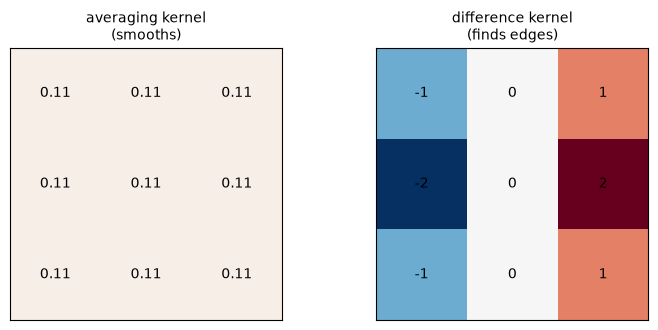

In [9]:
mean_kernel = np.ones((3, 3)) / 9
edge_kernel = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4))
for ax, (kernel, title) in zip(axes, [(mean_kernel, "averaging kernel\n(smooths)"),
                                      (edge_kernel, "difference kernel\n(finds edges)")]):
    ax.imshow(kernel, cmap="RdBu_r", vmin=-2, vmax=2)
    for (i, j), v in np.ndenumerate(kernel):
        ax.text(j, i, f"{v:.2f}".rstrip("0").rstrip("."), ha="center", va="center", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### Gaussian smoothing

In practice you rarely build a smoothing kernel by hand. `ndi.gaussian_filter` does it for you.
Its one setting, `sigma`, controls how wide the averaging is, measured in pixels — bigger sigma
averages over more neighbours, removing more grain but also blurring more real detail.

Watch what happens to the number of blobs.

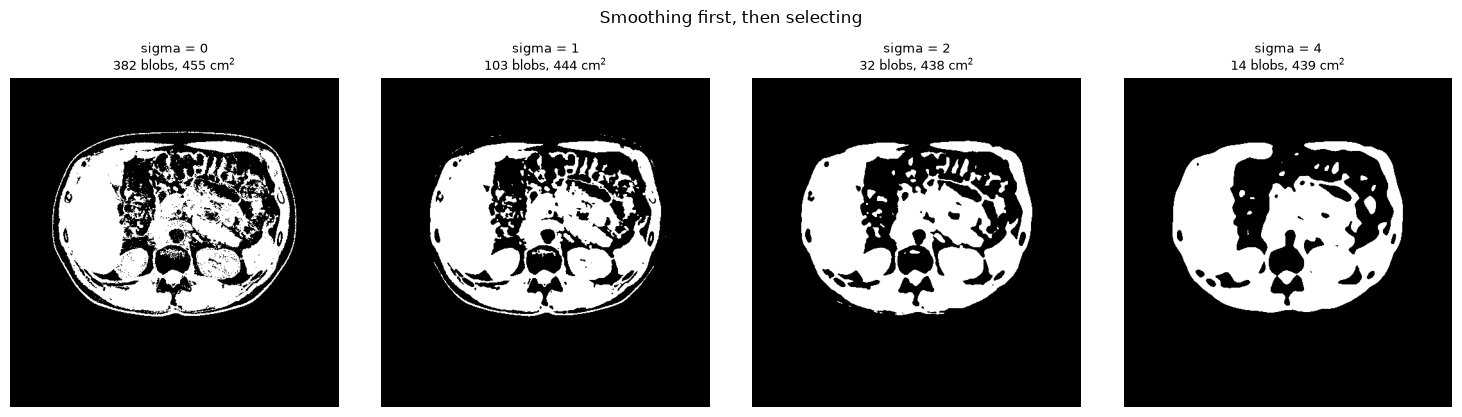

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, sigma in zip(axes, [0, 1, 2, 4]):
    smoothed = ndi.gaussian_filter(sl, sigma) if sigma else sl
    mask = body & (smoothed >= -29) & (smoothed < 150)
    _, n = ndi.label(mask)
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"sigma = {sigma}\n{n} blobs, {mask.sum() * px_area_cm2:.0f} cm$^2$",
                 fontsize=9)
    ax.axis("off")

fig.suptitle("Smoothing first, then selecting", y=1.03)
plt.tight_layout()
plt.show()

The blob count collapses while the measured area barely moves. That is the deal you are making:
you lose the grain-driven speckle and keep the measurement, at the cost of blurring real edges.

**More smoothing is not automatically better.** By `sigma = 4` thin structures have merged into
their neighbours and small ones have disappeared. Chapter 5 uses a modest sigma for exactly this
reason: enough to steady the measurement, not enough to erase the thin sheets of tissue that
separate one fat compartment from another.

### Median filtering

A Gaussian *averages*, so one extreme pixel still drags its neighbourhood with it.

A **median** filter instead takes the middle value of the neighbourhood. One wild pixel cannot move
a middle value, so outliers are removed completely. It also keeps edges crisp instead of ramping
them into a gradient.

For CT — where metal implants and reconstruction artefacts produce isolated extreme values — this
is often the better first move.

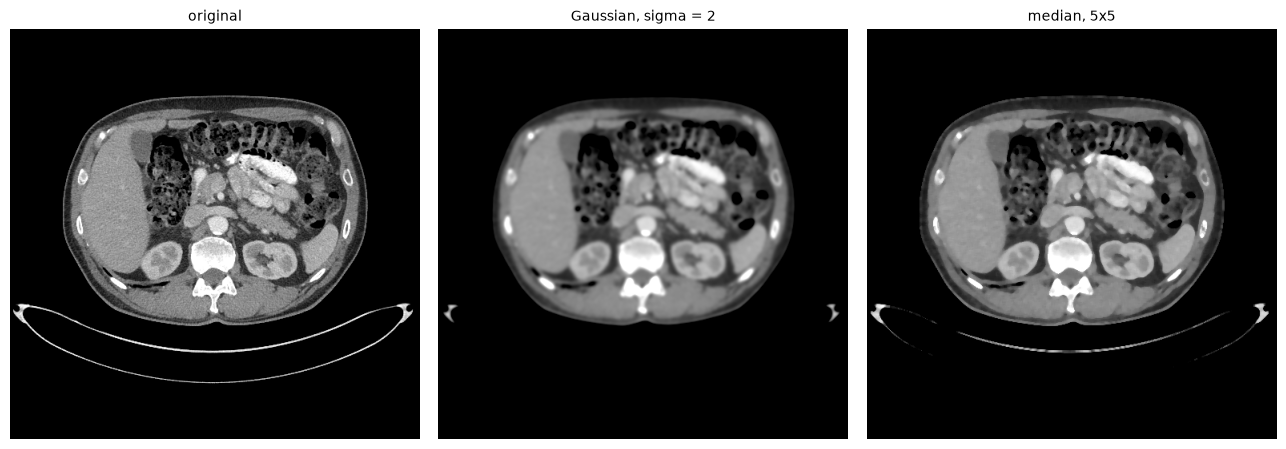

In [11]:
gauss = ndi.gaussian_filter(sl, 2)
median = ndi.median_filter(sl, size=5)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (img, title) in zip(axes, [(sl, "original"),
                                   (gauss, "Gaussian, sigma = 2"),
                                   (median, "median, 5x5")]):
    ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

The difference is easiest to see by taking a single horizontal line of pixels and plotting its
values. Where the tissue changes, the original has a sharp step buried in grain. The Gaussian keeps
the grain down but softens the step into a slope. The median keeps the step square.

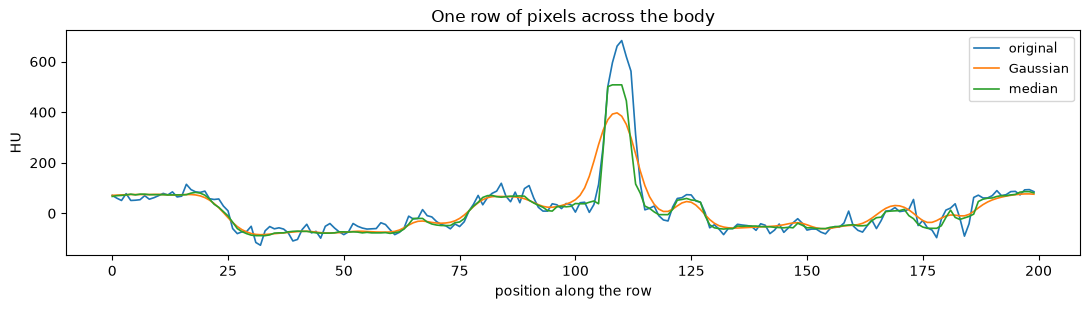

In [12]:
row = sl.shape[0] // 2

fig, ax = plt.subplots(figsize=(11, 3.2))
for img, label in [(sl, "original"), (gauss, "Gaussian"), (median, "median")]:
    ax.plot(img[row, 150:350], label=label, linewidth=1.2)
ax.set_title("One row of pixels across the body")
ax.set_ylabel("HU")
ax.set_xlabel("position along the row")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Cleaning up by shape

Filtering the *image* reduces the speckle. Cleaning the *mask* removes what is left — and it works
on shape rather than brightness, so it fixes problems no filter can.

Three operations do nearly all the work:

- **Opening** shrinks the mask a little, then grows it back. Small specks vanish during the
  shrinking and never come back; large regions return to their original size.
- **Closing** is the reverse — grow then shrink. It plugs small gaps without inflating the outline.
- **Filling holes** closes enclosed empty patches.

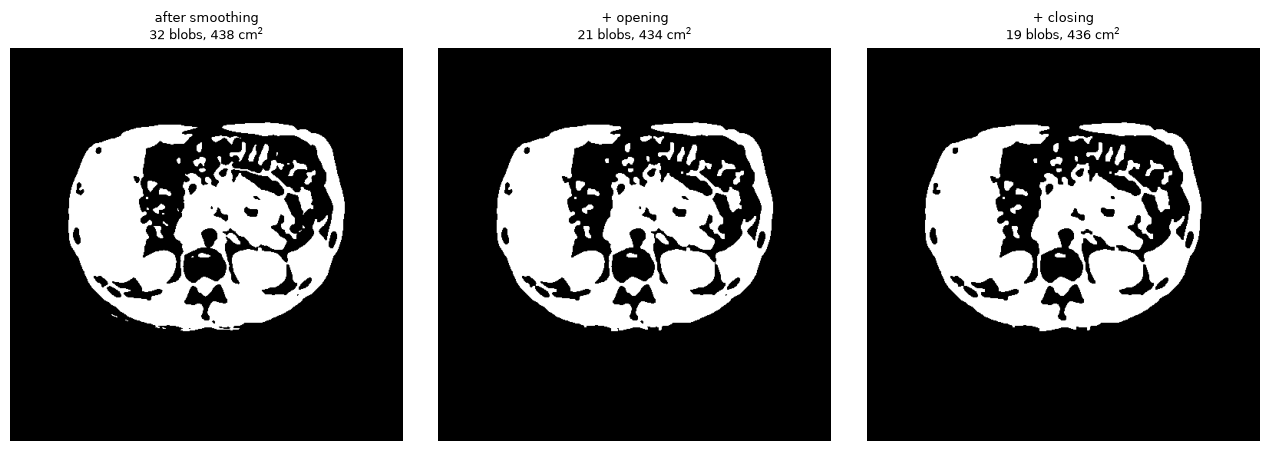

In [13]:
muscle_raw = body & (gauss >= -29) & (gauss < 150)
muscle_open = ndi.binary_opening(muscle_raw, np.ones((3, 3)))
muscle_clean = ndi.binary_closing(muscle_open, np.ones((3, 3)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (mask, title) in zip(axes, [(muscle_raw, "after smoothing"),
                                    (muscle_open, "+ opening"),
                                    (muscle_clean, "+ closing")]):
    _, n = ndi.label(mask)
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"{title}\n{n} blobs, {mask.sum() * px_area_cm2:.0f} cm$^2$", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Finding edges

An edge is a place where brightness changes quickly. "How quickly it changes" is the **gradient**.

The **Sobel** filter measures the gradient in one direction — left-to-right or top-to-bottom.
Measure both and combine them with Pythagoras, and you get edge strength that does not depend on
which way the edge happens to run:

$$\text{edge strength} = \sqrt{(\text{change across})^2 + (\text{change down})^2}$$

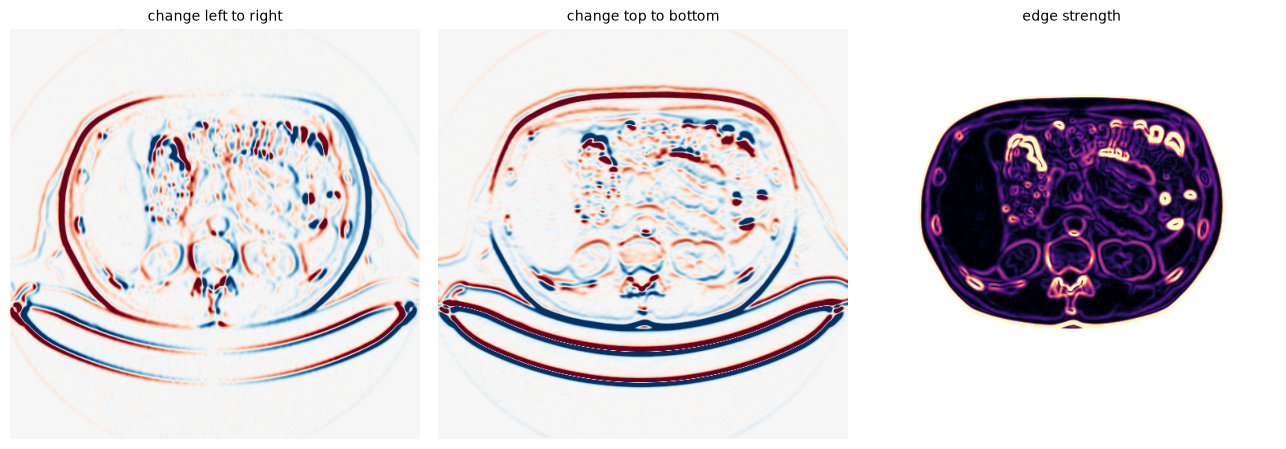

In [14]:
gx = ndi.sobel(gauss, axis=1)     # change from left to right
gy = ndi.sobel(gauss, axis=0)     # change from top to bottom
strength = np.hypot(gx, gy)       # sqrt(gx**2 + gy**2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(gx, cmap="RdBu_r", vmin=-400, vmax=400)
axes[0].set_title("change left to right", fontsize=10)
axes[1].imshow(gy, cmap="RdBu_r", vmin=-400, vmax=400)
axes[1].set_title("change top to bottom", fontsize=10)
axes[2].imshow(np.where(body, strength, np.nan), cmap="magma", vmin=0, vmax=600)
axes[2].set_title("edge strength", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The bright ring tracing the belly is the boundary between the fat just under the skin and the
muscle layer beneath it. Chapter 5 has to find that boundary to tell **subcutaneous** fat (under the
skin) from **visceral** fat (around the organs).

And this is where brightness alone runs out of road.

Look again at the muscle mask: it contains the liver, the spleen and the kidneys. Those organs are
not muscle, but they sit in the same HU range. **No cut-off can separate them, because there is no
brightness difference to use.** Telling them apart needs knowledge of anatomy — of what organ is
where — which is exactly why Chapter 5 brings in a trained neural network instead of pushing
thresholds harder.

Knowing *why* a simple method fails is what tells you when to reach for a complicated one.

## 7. Putting it together

Here is the whole pipeline as one reusable function. The order matters: smooth, then find the
patient, then select, then tidy up.

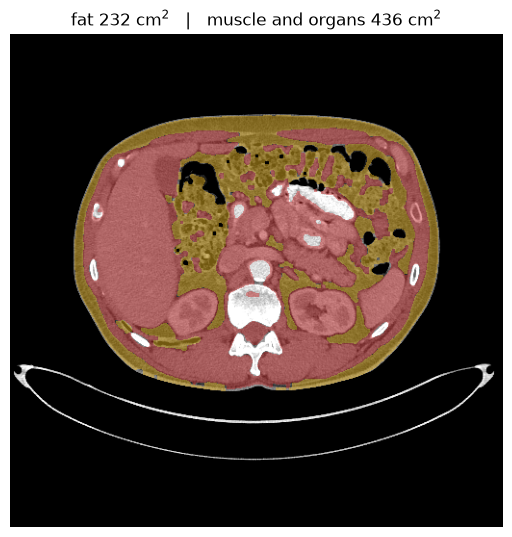

In [15]:
def compartment(slice_hu, lo, hi, sigma=2, cleanup=3):
    """Select tissue between lo and hi HU, inside the body, cleaned up."""
    smoothed = ndi.gaussian_filter(slice_hu.astype(np.float32), sigma)
    inside = body_mask(slice_hu)
    mask = inside & (smoothed >= lo) & (smoothed < hi)
    mask = ndi.binary_opening(mask, np.ones((cleanup, cleanup)))
    return ndi.binary_closing(mask, np.ones((cleanup, cleanup)))


fat_mask = compartment(sl, -190, -30)
soft_mask = compartment(sl, -29, 150)

overlay = np.zeros(sl.shape + (3,))
overlay[fat_mask] = [1.0, 0.78, 0.15]      # yellow
overlay[soft_mask] = [0.80, 0.15, 0.15]    # red

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(sl, cmap="gray", vmin=-160, vmax=240)
ax.imshow(overlay, alpha=np.where(fat_mask | soft_mask, 0.45, 0.0))
ax.set_title(f"fat {fat_mask.sum() * px_area_cm2:.0f} cm$^2$   |   "
             f"muscle and organs {soft_mask.sum() * px_area_cm2:.0f} cm$^2$")
ax.axis("off")
plt.show()

That picture is, in miniature, what Chapter 5 does properly: pick a slice, select the tissues,
count the pixels, convert to square centimetres.

## Exercises

1. Change the `-500` in `body_mask` to `-200` and then to `-800`. What breaks in each case, and why
   is −500 a sensible default?
2. Measure the fat area for sigma from 0 to 6 and plot the result. Does it settle down? What does
   that tell you about how much the answer depends on your choice?
3. Run `compartment` on ten slices in a row and plot fat area against slice number. How much does
   the answer depend on *which* slice you happened to pick? (Chapter 5 has to solve this.)
4. Try to exclude the liver from the muscle mask using only what is in this chapter. Where does it
   break down, and what extra information would you need?

## References

- [scipy.ndimage documentation](https://docs.scipy.org/doc/scipy/reference/ndimage.html)
- Mitsiopoulos N, et al. *Cadaver validation of skeletal muscle measurement by MRI and computerized
  tomography.* J Appl Physiol. 1998;85(1):115–122. — where the −29 to +150 HU muscle range
  originally came from.
- Roth H, et al. (2016). *Data From Pancreas-CT.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)